In [1]:
# from dotenv import load_dotenv
# load_dotenv()

In [2]:
# import os

# os.environ['LD_LIBRARY_PATH'] = '/home/baris/miniconda3/envs/verifiers/lib/python3.11/site-packages/nvidia/nvjitlink/lib'

In [3]:
import json
import textwrap
import pandas as pd
from ipywidgets import widgets
from IPython.display import display
from ipywidgets import HBox
import matplotlib.pyplot as plt
from tabulate import tabulate


In [4]:
df = pd.read_json("../data/generated/predictions.jsonl", lines=True)
df.head()

,id,answer,prompt,docs,answers,supporting_titles,trajectory
0,2hop__734582_71302,Vito Corleone,[{'content': 'Answer the question based on the...,"[{'id': 0, 'is_supporting': False, 'text': '# ...","[vito andolini, Vito Corleone, vito corleone, ...","[The Good Shepherd (film), The Godfather Part II]",[{'content': 'Answer the question based on the...
1,2hop__700093_455653,Rohana Wijeweera,[{'content': 'Answer the question based on the...,"[{'id': 0, 'is_supporting': False, 'text': '# ...","[rohana wijeweera, Rohana Wijeweera]","[Rohana Wijeweera, Dimuthu Bandara Abayakoon]",[{'content': 'Answer the question based on the...
2,2hop__203955_25719,406,[{'content': 'Answer the question based on the...,"[{'id': 0, 'is_supporting': False, 'text': '# ...",[406],"[Rössen culture, Galicia (Spain)]",[{'content': 'Answer the question based on the...
3,2hop__83800_747874,Jamie Murray,[{'content': 'Answer the question based on the...,"[{'id': 0, 'is_supporting': False, 'text': '# ...","[jamie murray, Jamie Murray]","[2011 Valencia Open 500 – Doubles, 2016 Wimble...",[{'content': 'Answer the question based on the...
4,2hop__21104_16334,modern-day Italians,[{'content': 'Answer the question based on the...,"[{'id': 0, 'is_supporting': False, 'text': '# ...","[modern-day italians, modern-day Italians]","[Jews, Ashkenazi Jews]",[{'content': 'Answer the question based on the...


In [5]:
from verifiers.rubrics.musique import musique_f1_reward_func, musique_em_reward_func, musique_supporting_recall_reward_func, musique_supporting_f1_reward_func

em_rewards = musique_em_reward_func(df['trajectory'].values, df['answers'].values)
df['reward.em'] = em_rewards

f1_rewards = musique_f1_reward_func(df['trajectory'].values, df['answers'].values)
df['reward.f1'] = f1_rewards

supporting_f1_rewards = musique_supporting_f1_reward_func(df['trajectory'].values, df['supporting_titles'].values)
df['reward.supporting_f1'] = supporting_f1_rewards

supporting_recall_rewards = musique_supporting_recall_reward_func(df['trajectory'].values, df['supporting_titles'].values)
df['reward.supporting_recall'] = supporting_recall_rewards

In [6]:
df.head()

,id,answer,prompt,docs,answers,supporting_titles,trajectory,reward.em,reward.f1,reward.supporting_f1,reward.supporting_recall
0,2hop__734582_71302,Vito Corleone,[{'content': 'Answer the question based on the...,"[{'id': 0, 'is_supporting': False, 'text': '# ...","[vito andolini, Vito Corleone, vito corleone, ...","[The Good Shepherd (film), The Godfather Part II]",[{'content': 'Answer the question based on the...,1,1.0,1.000000,1.0
1,2hop__700093_455653,Rohana Wijeweera,[{'content': 'Answer the question based on the...,"[{'id': 0, 'is_supporting': False, 'text': '# ...","[rohana wijeweera, Rohana Wijeweera]","[Rohana Wijeweera, Dimuthu Bandara Abayakoon]",[{'content': 'Answer the question based on the...,1,1.0,1.000000,1.0
2,2hop__203955_25719,406,[{'content': 'Answer the question based on the...,"[{'id': 0, 'is_supporting': False, 'text': '# ...",[406],"[Rössen culture, Galicia (Spain)]",[{'content': 'Answer the question based on the...,0,0.0,0.400000,0.5
3,2hop__83800_747874,Jamie Murray,[{'content': 'Answer the question based on the...,"[{'id': 0, 'is_supporting': False, 'text': '# ...","[jamie murray, Jamie Murray]","[2011 Valencia Open 500 – Doubles, 2016 Wimble...",[{'content': 'Answer the question based on the...,1,1.0,1.000000,1.0
4,2hop__21104_16334,modern-day Italians,[{'content': 'Answer the question based on the...,"[{'id': 0, 'is_supporting': False, 'text': '# ...","[modern-day italians, modern-day Italians]","[Jews, Ashkenazi Jews]",[{'content': 'Answer the question based on the...,0,0.0,0.666667,0.5


In [7]:
df[['reward.em', 'reward.f1', 'reward.supporting_f1', 'reward.supporting_recall']].describe()

,reward.em,reward.f1,reward.supporting_f1,reward.supporting_recall
count,300.000000,300.000000,300.000000,300.000000
mean,0.373333,0.463354,0.752929,0.686389
std,0.484498,0.465612,0.240603,0.269286
min,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.666667,0.500000
50%,0.000000,0.400000,0.800000,0.666667
75%,1.000000,1.000000,1.000000,1.000000
max,1.000000,1.000000,1.000000,1.000000


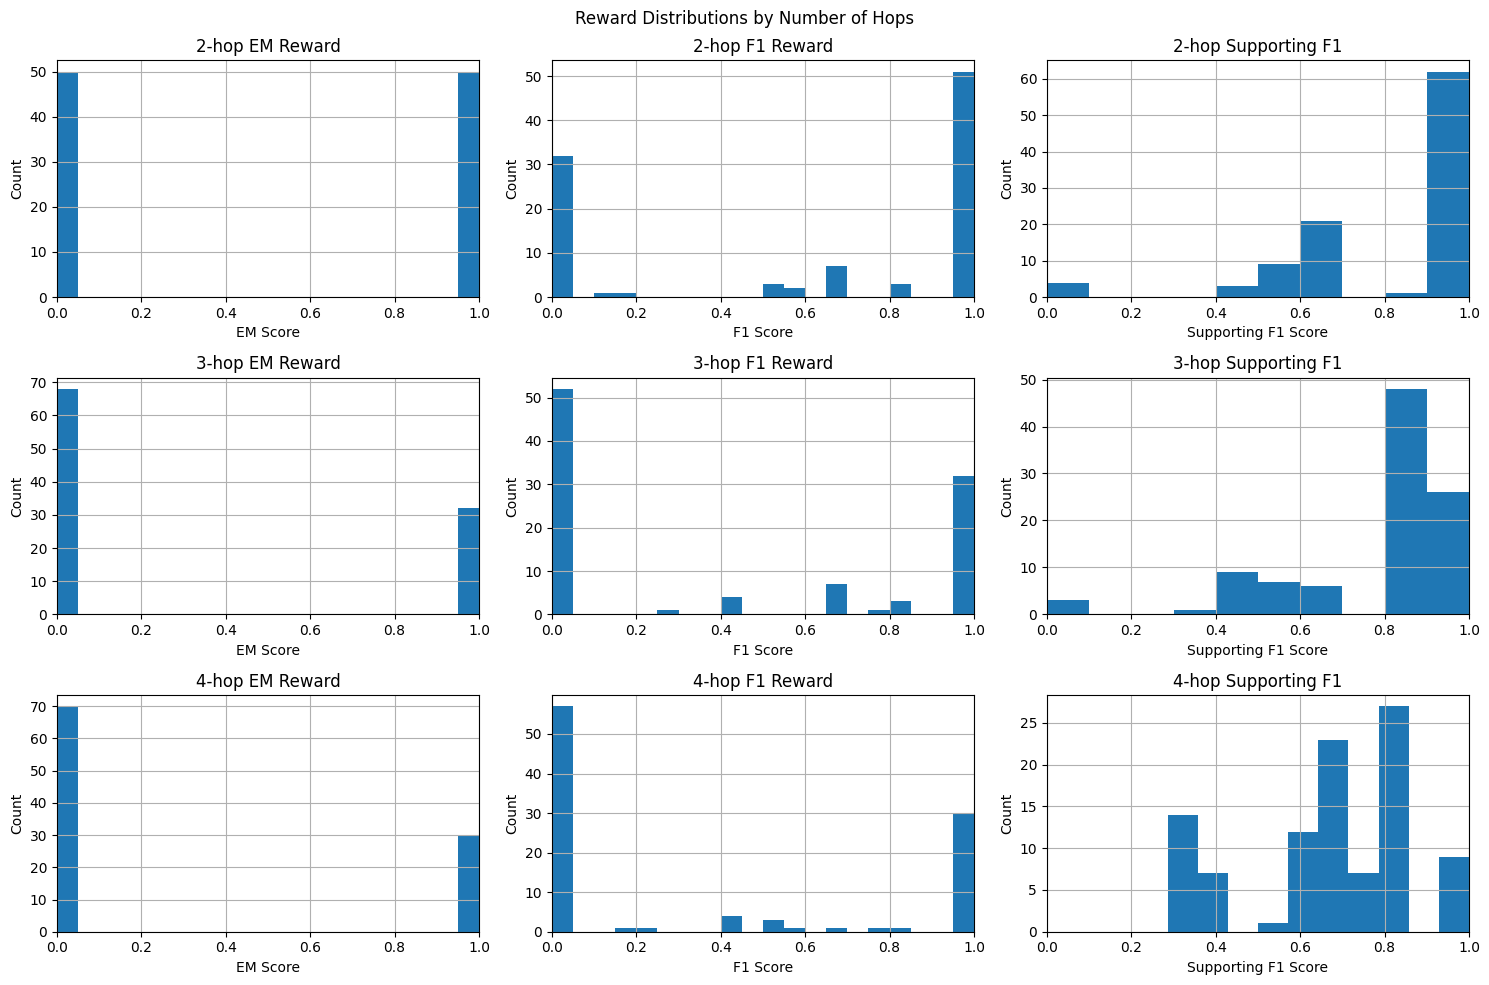

In [8]:
# Visualize rewards per n_hops
df['n_hops'] = df['supporting_titles'].apply(len)
n_hops = sorted(df['n_hops'].unique())
fig, axes = plt.subplots(len(n_hops), 3, figsize=(15, 10))
fig.suptitle('Reward Distributions by Number of Hops')

for i, n_hop in enumerate(n_hops):
    subset = df[df['n_hops'] == n_hop]
    
    subset['reward.em'].hist(ax=axes[i,0], bins=20)
    axes[i,0].set_title(f'{n_hop}-hop EM Reward')
    axes[i,0].set_xlabel('EM Score')
    axes[i,0].set_ylabel('Count')
    axes[i,0].set_xlim(0, 1)
    
    subset['reward.f1'].hist(ax=axes[i,1], bins=20)
    axes[i,1].set_title(f'{n_hop}-hop F1 Reward')
    axes[i,1].set_xlabel('F1 Score')
    axes[i,1].set_ylabel('Count')
    axes[i,1].set_xlim(0, 1)
    
    subset['reward.supporting_f1'].hist(ax=axes[i,2])
    axes[i,2].set_title(f'{n_hop}-hop Supporting F1')
    axes[i,2].set_xlabel('Supporting F1 Score')
    axes[i,2].set_ylabel('Count')
    axes[i,2].set_xlim(0, 1)


plt.tight_layout()


In [9]:
import textwrap
from IPython.display import display
import ipywidgets as widgets
from ipywidgets import HBox

def fixedwidth(text):
    if not isinstance(text, str):
        text = str(text)
    return "\n".join(textwrap.wrap(text, width=80, replace_whitespace=False))

def format_row(row):
    output = []
    output.append(f"{row['id']} - {row['n_hops']} hops")
    output.append("="*80)
    output.append("Q: " + row['prompt'][0]['content'])
    output.append("Reference Answers: " + str(row['answers']))
    output.append("Predicted Answer: " + str(row['answer']))
    output.append("")
    output.append("# Scores")
    output.append("EM: {:.3f}".format(row['reward.em']))
    output.append("F1: {:.3f}".format(row['reward.f1']))
    output.append("Supporting F1: {:.3f}".format(row['reward.supporting_f1']))
    output.append("Supporting Recall: {:.3f}".format(row['reward.supporting_recall']))
    output.append("")
    output.append("Supporting Titles: " + str(row['supporting_titles']))
    return "\n".join(output)

def present_row(row):
    print(format_row(row))

def create_browse_app(df):
    def browse_failed(i=0):
        row = df.iloc[i]
        present_row(row)

    index = widgets.IntText(value=0, description='Index:')
    left_button = widgets.Button(description='Previous')
    right_button = widgets.Button(description='Next')

    def on_left_button_clicked(b):
        if index.value > 0:
            index.value -= 1

    def on_right_button_clicked(b):
        if index.value < len(df) - 1:
            index.value += 1

    left_button.on_click(on_left_button_clicked)
    right_button.on_click(on_right_button_clicked)

    ui = HBox([left_button, index, right_button])
    out = widgets.interactive_output(browse_failed, {'i': index})

    display(ui, out)

# Create app focused on failed examples
inspect_df = df[df['reward.f1'] < 1.0].sort_values('reward.f1')
create_browse_app(inspect_df)


Output()